In [3]:
import rosalia as rs
import sys
# sys.path.append("/Users/aborlaff/NASA/EPHESSOS/")

In [4]:
import ephessos as ep
print(ep.__file__)

/Users/aborlaff/NASA/EPHESSOS/ephessos/__init__.py


In [79]:
# Telescope definition object 
# telescope = {"pointing": [RA_TARG, DEC_TARG], "PA_Y": PA_Y, "detector_shape": [NAXIS1, NAXIS2], "pixscale": pixscale,
#              "R_mirror": R_mirror, "OBSLOC": OBSLOC, "EXPSTART": EXPSTART, "EXPTIME": EXPTIME}

class exposure():
    import numpy as np 
    
    def __init__(self, filename=None, telescope=None):
        if telescope is not None: 
            import numpy as np 
            self.TELESCOP = telescope['TELESCOP']
            self.DATA_SHAPE = telescope['DATA_SHAPE']
            self.RA_TARG = telescope["pointing"][0]
            self.DEC_TARG = telescope["pointing"][1]
            self.PA = telescope['PA_Y']
            self.EXPSTART = telescope['EXPSTART']
            self.EXPTIME = telescope['EXPTIME']
            # self.PHYSPIX = telescope['PHYSPIX']
            self.PIXSCALE = telescope['PIXSCALE']
            # self.EXPSTART_ISOT = 
            self.OBSLOC = telescope['OBSLOC']
            self.FILTER_IDENTITY = rs.telescopes.find_filter_in_svo(wavelength=telescope["FILTER_PARAMS"]["NAME"],
                                                                    telescope=telescope["FILTER_PARAMS"]["TELESCOPE"],
                                                                    instrument=telescope["FILTER_PARAMS"]["INSTRUMENT"],
                                                                    detector=telescope["FILTER_PARAMS"]["DETECTOR"], verbose=False)
            # self.XYZ_HELIO_POS = exposure_identity['XYZ_HELIO_POS']
            self.SCIEXTS = [0]

            header = rs.utils.create_custom_wcs(crpix=np.array(self.DATA_SHAPE)/2, 
                                                         crval=[self.RA_TARG, self.DEC_TARG], 
                                                         cdelt=[-self.PIXSCALE,self.PIXSCALE], 
                                                         crota=[-self.PA,-self.PA], 
                                                         projection="TAN")
            
            header["NAXIS1"] = self.DATA_SHAPE[0]
            header["NAXIS2"] = self.DATA_SHAPE[1]
            self.ASTROPYWCS = [astropy_wcs.WCS(header)]
            

        if filename is not None:
            exposure_identity = rs.utils.exposure_inspector(filename, lite=True)
        
            self.FILENAME = exposure_identity['FILENAME']
            self.TELESCOP = exposure_identity['TELESCOP']
            self.INSTRUME = exposure_identity['INSTRUME']
            self.DETECTOR = exposure_identity['DETECTOR']
            self.RA_TARG = exposure_identity['RA_TARG']
            self.DEC_TARG = exposure_identity['DEC_TARG']
            self.EXPSTART = exposure_identity['EXPSTART']
            self.EXPTIME = exposure_identity['EXPTIME']
            self.BUNIT = exposure_identity['BUNIT']
            self.EXPSTART_ISOT = exposure_identity['EXPSTART_ISOT']
            self.PA = exposure_identity['PA']
            self.SCA = exposure_identity['SCA']
            self.HST_TYPE = exposure_identity['HST_TYPE']
            self.FILTER = exposure_identity['FILTER']
            self.FILTER_IDENTITY = exposure_identity['FILTER_IDENTITY']
            self.PHYSPIX = exposure_identity['PHYSPIX']
            self.PIXSCALE = exposure_identity['PIXSCALE']
            self.SCIEXTS = exposure_identity['SCIEXTS']
            self.DATA_SHAPE = exposure_identity['DATA_SHAPE']
            self.ASTROPYWCS = exposure_identity['ASTROPYWCS']
            self.FILETYPE = exposure_identity['FILETYPE']
            self.XYZ_HELIO_POS = exposure_identity['XYZ_HELIO_POS']
            self.FPA_NEAR_RADIUS = self.get_max_angular_size()/4

    def get_detector_corners(self):
        detector_corners = []
        for i in range(len(self.SCIEXTS)):
            detector_corners.append(rs.detectors.get_detector_corners(self.ASTROPYWCS[i]))
        return(detector_corners)
    
    def get_max_angular_size(self):
        return(rs.utils.find_max_angular_size_of_image(wcs=self.ASTROPYWCS, ra_cen=self.RA_TARG, dec_cen=self.DEC_TARG))
    

    def plot_footprint(self, ax=None, color='red', label=None, **kwargs):
        import numpy as np
        import matplotlib.pyplot as plt
        
        ra_dec_constraints = rs.gaia.find_ra_dec_constraints(self.RA_TARG, self.DEC_TARG, radius=self.FPA_NEAR_RADIUS, verbose=False)
        exp_corners = self.get_detector_corners()

        if ax is None:
            fig, ax = plt.subplots(figsize=(8,8))
        for i in range(len(self.SCIEXTS)):
            x = np.array(exp_corners[i]["corners_world"][:,0].tolist() + [exp_corners[i]["corners_world"][0,0]])
            y = np.array(exp_corners[i]["corners_world"][:,1].tolist() + [exp_corners[i]["corners_world"][0,1]])
            ax.plot(x, y, color=color, label=label, **kwargs)
            ax.set_xlim(ra_dec_constraints["ra_max"], ra_dec_constraints["ra_min"])
            ax.set_ylim(ra_dec_constraints["dec_min"], ra_dec_constraints["dec_max"])
            ax.set_xlabel("Right Ascension (degree)")
            ax.set_ylabel("Declination (degree)")
        return(ax)
    
    def find_nearby_ssos(self):
        import ephessos as ep 
        sso_cone_search = ep.core.cone_search(ra=self.RA_TARG, dec=self.DEC_TARG, mjd=self.EXPSTART, search_radius=self.FPA_NEAR_RADIUS, verbose=False)
        return(sso_cone_search)

    def get_nearby_sources(self, g_mag_max=15):
        hybrid_catalog = rs.psf.get_hybrid_catalog(ra=self.RA_TARG, dec=self.DEC_TARG,
                                                   radius=1,
                                                   lambda_ref=lambda_ref,
                                                   MJD=MJD,
                                                   observer=telescope,
                                                   g_mag_max = g_mag_max,
                                                   verbose=verbose,
                                                   query_filename=source_catalog_filename)

TELESCOP="STARFOX"
RA_TARG = 100
DEC_TARG = 23
PA_Y = 32
NAXIS1=2048
NAXIS2=4096
PIXSCALE=8/60/60
R_mirror=1
OBSLOC=None
EXPSTART=61000
EXPTIME=600
FILTER_PARAMS={"NAME": "F606W", "TELESCOPE": "HST", "INSTRUMENT": "ACS", "DETECTOR": "WFC"}

telescope = {"TELESCOP":TELESCOP, "pointing": [RA_TARG, DEC_TARG], "PA_Y": PA_Y, "DATA_SHAPE": [NAXIS1, NAXIS2], "PIXSCALE": PIXSCALE,
             "R_mirror": R_mirror, "FILTER_PARAMS":FILTER_PARAMS, "OBSLOC": OBSLOC, "EXPSTART": EXPSTART, "EXPTIME": EXPTIME}

custom_exposure = exposure(telescope=telescope)


In [80]:
custom_exposure.get_detector_corners()

[{'corners_pix': array([[   0,    0],
         [2048,    0],
         [2048, 4096],
         [   0, 4096]]),
  'corners_world': array([[ 99.49463742,  17.95009874],
         [ 95.38366005,  20.29062089],
         [100.54317388,  28.05425597],
         [104.79909317,  25.57641679]])}]

{'filter_id': 'HST/ACS_WFC.F606W',
 'filter_transmission_curve': <Table length=2715>
 Wavelength Transmission
  Angstrom              
  float64     float64   
 ---------- ------------
     4569.0  9.66764e-05
     4570.0   0.00010671
     4571.0   0.00011673
     4572.0  0.000126749
     4573.0  0.000136765
     4574.0  0.000146779
     4575.0   0.00015679
     4576.0  0.000166799
     4577.0  0.000176806
        ...          ...
     7275.0  0.000127173
     7276.0  0.000123225
     7277.0  0.000119279
     7278.0  0.000115334
     7279.0  0.000111391
     7280.0   0.00010745
     7281.0  0.000103509
     7282.0  9.95689e-05
     7283.0  9.56309e-05,
 'filter_lambda_ref': <Quantity 5809.25977515 Angstrom>,
 'filter_lambda_min': <Quantity 4681. Angstrom>,
 'filter_lambda_max': <Quantity 7118. Angstrom>,
 'filter_lambda_width': <Quantity 1771.88043556 Angstrom>,
 'filter_transmission_ref': array(0.41824189),
 'wavelength': 'F606W',
 'telescope': 'HST',
 'instrument': 'ACS',
 'detector'

/Users/aborlaff/NASA/ROSALIA_DEVEL/notebooks/CAR/WFI_F129_RA_085.533_DEC_-50.397_MJD_61365.00000_PA_142.21.fits
Updating Minor Planet Center Orbits (once daily) ...


100%|██████████| 92.4M/92.4M [00:21<00:00, 4.25MB/s]


Updating xephem MPCORB catalogue...


ValueError: unrecognised format for observatory: None

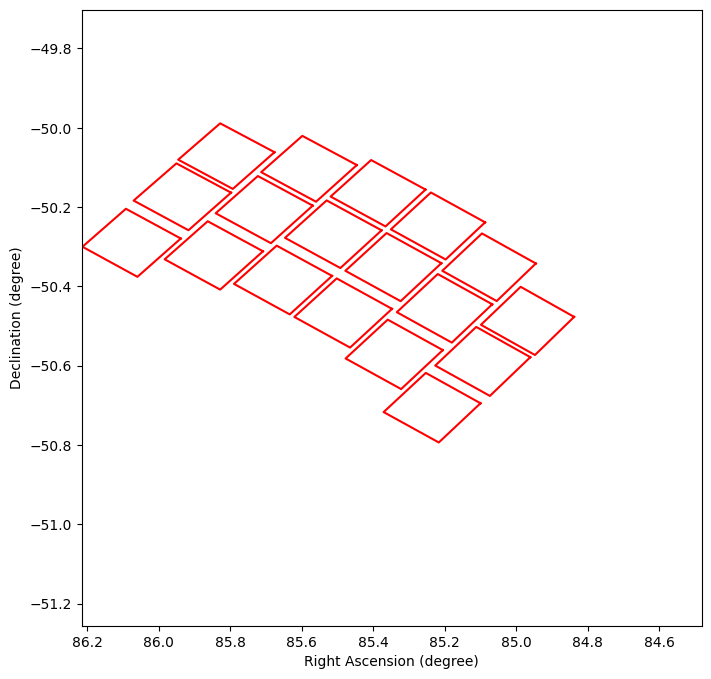

In [12]:
import glob
roman_fits = glob.glob("/Users/aborlaff/NASA/ROSALIA_DEVEL/notebooks/CAR/WFI*[0-9].fits")

for i in range(len(roman_fits)):
    print(roman_fits[i])
    roman_exposure = exposure(roman_fits[i])
    roman_exposure.plot_footprint()
    roman_exposure.find_nearby_ssos()

In [ ]:
(/60/60*4096)**2

54.69424197530865

In [ ]:
# roman_exposure.get_detector_corners()
rs.utils.find_max_angular_size_of_image(wcs=roman_exposure.ASTROPYWCS)    

In [24]:
ep.core.get_last_mpcorb()

Using Minor Planet Center cached file: Last: 2026-04-28T15:04:43.719


'/Users/aborlaff/NASA/EPHESSOS/ephessos/MPCORB.DAT'

In [25]:
exp_corners[0]["corners_world"][:,0].tolist()

NameError: name 'exp_corners' is not defined

In [ ]:
import pympc 
pympc.update_catalogue()